# 📊 Análise de Receita - Telecom (T-Test)

## 🎯 Problema de Negócio

Queremos responder:

Clientes com plano premium geram maior receita média (ARPU)
em comparação com clientes de plano padrão?

## 💼 Impacto

Essa análise pode apoiar decisões estratégicas como:

- Estratégias de upsell
- Definição de pricing
- Segmentação de clientes
- Otimização de campanhas comerciais

In [15]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

In [16]:
import pandas as pd

df = pd.read_csv("../data/telecom_data.csv")

df.head()

,customer_id,plan_type,arpu
0,1,premium,132
1,2,standard,85
2,3,premium,145
3,4,standard,78
4,5,premium,120


## 🧹 Preparação e Entendimento dos Dados

Nesta etapa, realizamos a preparação e análise inicial dos dados,
com o objetivo de garantir qualidade e compreender a estrutura do dataset.

### 📥 Carregamento dos Dados
Carregamos o dataset contendo informações de clientes de telecomunicações.

### 🔍 Estrutura dos Dados
Analisamos:
- Tipos de dados
- Quantidade de registros
- Possíveis valores ausentes

### 📊 Distribuição dos Grupos
Verificamos a quantidade de clientes por tipo de plano:
- Premium
- Standard

### 📈 Estatísticas Iniciais
Calculamos métricas como a média de receita (ARPU) por grupo,
para identificar diferenças preliminares antes do teste estatístico.

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  60 non-null     int64
 1   plan_type    60 non-null     str  
 2   arpu         60 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.5 KB


In [18]:
df["plan_type"].value_counts()

plan_type
premium     30
standard    30
Name: count, dtype: int64

In [19]:
df.groupby("plan_type")["arpu"].mean()

plan_type
premium     140.300000
standard     89.866667
Name: arpu, dtype: float64

In [20]:
# Separar os grupos
arpu_premium = df[df["plan_type"] == "premium"]["arpu"]
arpu_standard = df[df["plan_type"] == "standard"]["arpu"]

## 📈 Visualização dos Dados

Nesta etapa, analisamos a distribuição da receita (ARPU)
entre clientes dos planos premium e standard.

O objetivo é verificar visualmente se existe diferença entre os grupos
antes da validação estatística.

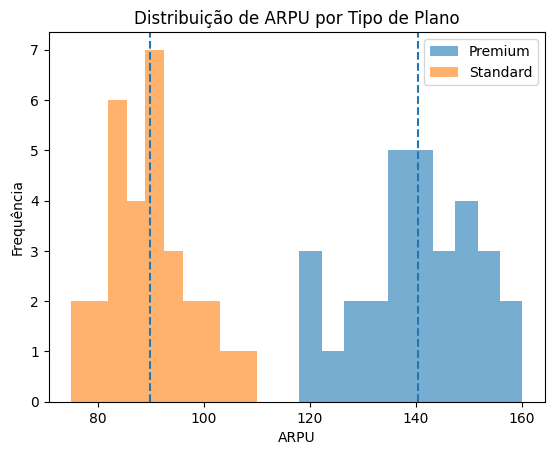

In [28]:
import matplotlib.pyplot as plt

plt.hist(arpu_premium, alpha=0.6, label="Premium", bins=10)
plt.hist(arpu_standard, alpha=0.6, label="Standard", bins=10)

plt.legend()
plt.title("Distribuição de ARPU por Tipo de Plano")
plt.xlabel("ARPU")
plt.ylabel("Frequência")

plt.axvline(arpu_premium.mean(), linestyle="dashed")
plt.axvline(arpu_standard.mean(), linestyle="dashed")

# ✅ salvar ANTES do show
plt.savefig("../notebooks/arpu_distribution.png")

plt.show()

In [21]:
# Teste t
from scipy.stats import ttest_ind

t_stat, p_value_bilateral = ttest_ind(
    arpu_premium,
    arpu_standard,
    equal_var=False
)

p_value = p_value_bilateral / 2

print("t-stat:", t_stat)
print("p-value:", p_value)

# p-value ≤ 0.05 → rejeita H₀
# Rejeitamos H₀ com evidência extremamente forte

t-stat: 19.808278407543913
p-value: 3.493647343337416e-26


## 💼 Conclusão

Com base no teste estatístico realizado (t-test), foi possível identificar
que existe uma diferença significativa entre os grupos analisados.

Clientes com plano premium apresentam maior receita média (ARPU)
quando comparados aos clientes com plano padrão.

O p-value extremamente baixo indica que essa diferença dificilmente ocorreu ao acaso.

### 📊 Implicações de negócio

- Potencial para estratégias de upsell
- Otimização de receita
- Segmentação mais eficiente de clientes